# Lecture 4 — Backtesting (Part 1)
## Returns, averages, and constant-weight portfolios

This companion notebook uses the GAA framework to illustrate:

1. Simple, continuously compounded, and cumulative returns
2. Portfolio additivity (simple) vs. time additivity (log) of returns
3. Arithmetic vs. geometric average return
4. Performance & risk diagnostics via `analytics.timeseries_analyzer.TimeseriesAnalyzer`
5. A walk-forward constant-weight backtest via `backtesting.Backtester`

Data: monthly indexed performance from `perf_M.parquet`
(generated by `data/run_pipes.py`). Columns ending in `-i` are price-level indices.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analytics.timeseries_analyzer import TimeseriesAnalyzer
from backtesting import BacktestConfig, Backtester, BacktestResult

pd.set_option("display.float_format", "{:.4f}".format)

## 1. Load market data

Read the monthly parquet, pick a small multi-asset universe, and rename the columns to readable labels.

In [2]:
DATA_PATH = REPO_ROOT / "perf_M.parquet"

asset_map = {
    "MM_US_USD-i": "Money market",
    "FI_HY-i": "Global High Yield",
    "FI_IL_US-i": "U.S. TIPS",
    "FI_GB_US-i": "U.S. Treasuries",
    "FI_IG_ALL-i": "IG Bonds",
    "EQ_EA-i": "Equities ex-US",
    "EQ_EM-i": "EM Equities",
    "CO_GO-i": "Gold",
    "EQ_RE_NA-i": "Real Estate",
    "EQ_US-i": "S&P 500",
    "CO_xPM-i": "Commodities",
}

perf = pd.read_parquet(DATA_PATH)
prices = perf[list(asset_map)].rename(columns=asset_map).dropna()
prices = prices / prices.iloc[0] * 100  # reindex all series to 100 at the common start
print(f"Period: {prices.index[0].date()} \u2192 {prices.index[-1].date()}  ({len(prices)} months)")
prices.head()

Period: 2005-06-30 → 2025-12-31  (247 months)


,Money market,Global High Yield,U.S. TIPS,U.S. Treasuries,IG Bonds,Equities ex-US,EM Equities,Gold,Real Estate,S&P 500,Commodities
2005-06-30,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000
2005-07-31,100.2638,101.7697,97.9551,98.6442,99.4511,103.0800,107.0524,98.5842,106.8950,103.7572,104.8709
2005-08-31,100.5922,102.0887,100.1823,100.2108,100.4422,105.7165,108.0090,99.4192,102.3944,102.7960,113.4879
2005-09-30,100.8834,101.3103,100.0286,98.8811,99.9637,110.4428,118.0826,107.4903,102.3588,103.6754,118.4532
2005-10-31,101.2158,100.7207,98.7495,98.1076,99.3353,107.2200,110.3706,106.5998,99.9137,101.9736,110.4929


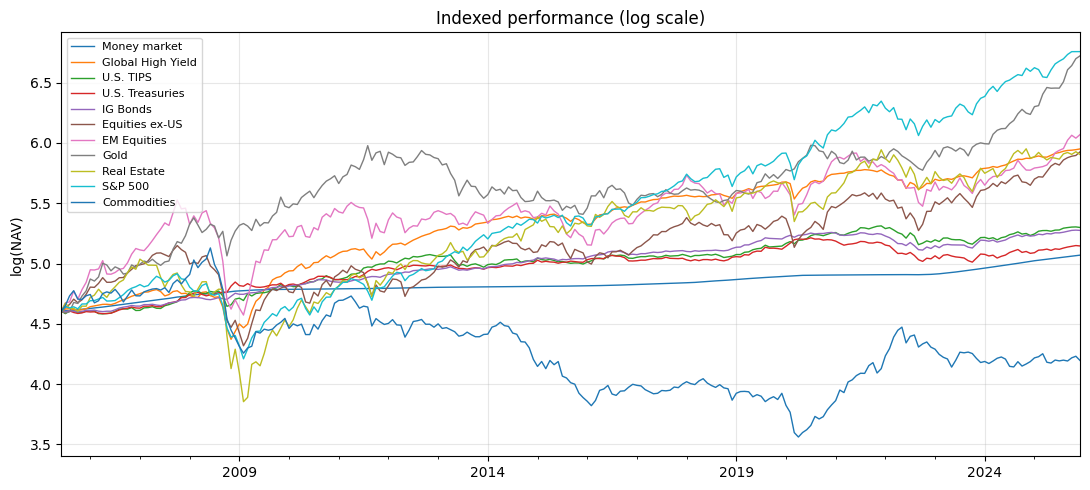

In [3]:
ax = np.log(prices).plot(figsize=(11, 5), linewidth=1.0)
ax.set_title("Indexed performance (log scale)")
ax.set_ylabel("log(NAV)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

## 2. Simple vs. continuously compounded returns

Given prices $P_t$ the **simple (discrete) return** is
$$ R_t = \frac{P_t - P_{t-1}}{P_{t-1}} $$
and the **continuously compounded (log) return** is
$$ r_t = \log(1+R_t) = \log P_t - \log P_{t-1}. $$

In [4]:
R = prices.pct_change().dropna()           # simple returns
r = np.log(prices).diff().dropna()         # log returns

pd.concat({"R (simple)": R.head(3), "r (log)": r.head(3)}, axis=1)[[
    ("R (simple)", "S&P 500"), ("r (log)", "S&P 500"),
    ("R (simple)", "U.S. Treasuries"), ("r (log)", "U.S. Treasuries"),
]]

,R (simple),r (log),R (simple),r (log)
,S&P 500,S&P 500,U.S. Treasuries,U.S. Treasuries
2005-07-31,0.0376,0.0369,-0.0136,-0.0137
2005-08-31,-0.0093,-0.0093,0.0159,0.0158
2005-09-30,0.0086,0.0085,-0.0133,-0.0134


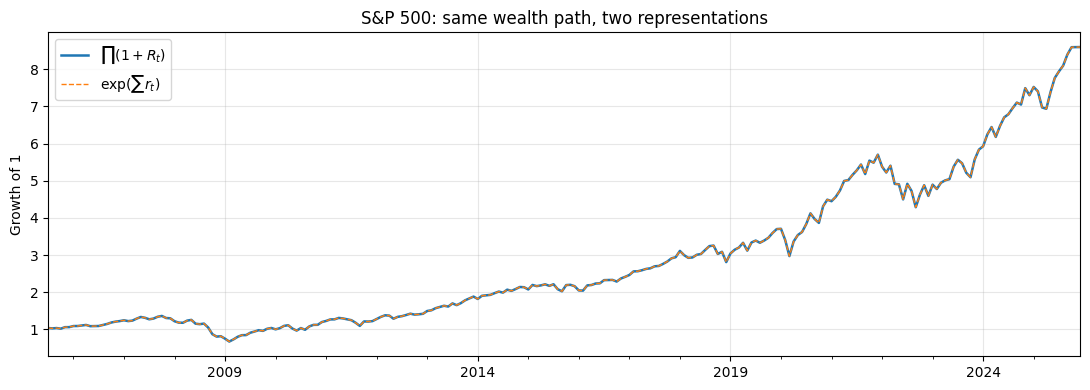

In [5]:
# Two equivalent ways to recover the price index:
#   simple returns  -> cumulative product of (1 + R_t)
#   log returns     -> cumulative sum of r_t, then exp
fig, ax = plt.subplots(figsize=(11, 4))
((1 + R["S&P 500"]).cumprod()).plot(ax=ax, label="$\\prod (1+R_t)$", linewidth=1.8)
(np.exp(r["S&P 500"].cumsum())).plot(ax=ax, label="$\\exp(\\sum r_t)$", linewidth=1.0, linestyle="--")
ax.set_title("S&P 500: same wealth path, two representations")
ax.set_ylabel("Growth of 1")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### 2.1 Portfolio additivity (simple) vs. time additivity (log)

Simple returns are **additive across assets**: $R_{p,t} = w^\top R_t$.
Log returns are **additive across time**: $r_{t:t+H} = \sum_{h=1}^{H} r_{t+h}$.
Neither identity holds for the *other* dimension.

In [6]:
# Portfolio additivity check: build a 60/40 portfolio, then compare
#   simple-return aggregation:  R_p = w^T R   (exact)
#   log-return  aggregation:    r_p = w^T r   (only an approximation)
w = pd.Series({"S&P 500": 0.6, "U.S. Treasuries": 0.4})
R_p_simple = R[w.index] @ w                               # exact portfolio return
r_p_logsum = r[w.index] @ w                               # weighted log returns (approx)
r_p_from_R = np.log1p(R_p_simple)                         # true log of portfolio return

diff = (r_p_logsum - r_p_from_R).abs()
print(f"Mean |w'r - log(1+w'R)| = {diff.mean():.6f}")
print(f"Max  |w'r - log(1+w'R)| = {diff.max():.6f}")
print("  -> simple returns aggregate exactly across assets; log returns do not.")

Mean |w'r - log(1+w'R)| = 0.000264
Max  |w'r - log(1+w'R)| = 0.004218
  -> simple returns aggregate exactly across assets; log returns do not.


In [7]:
# Time additivity check on a single asset over a 12-month window:
#   sum of monthly log returns  ==  log of (1 + annual simple return)
window = slice("2010-01-01", "2010-12-31")
asset = "S&P 500"
sum_r = r.loc[window, asset].sum()
annual_R = (1 + R.loc[window, asset]).prod() - 1
print(f"Sum of log returns  : {sum_r:.6f}")
print(f"log(1 + annual R)   : {np.log1p(annual_R):.6f}")
print(f"Sum of simple returns (NOT equal to annual R): {R.loc[window, asset].sum():.6f}")

Sum of log returns  : 0.143747
log(1 + annual R)   : 0.143747
Sum of simple returns (NOT equal to annual R): 0.161746


## 3. Arithmetic vs. geometric mean

Arithmetic mean: $\mu_{\text{arith}} = \frac{1}{T}\sum_t R_t$.
Geometric mean (CAGR-style): $\mu_{\text{geom}} = \big[\prod_t (1+R_t)\big]^{1/T} - 1 = \exp\!\big(\bar{r}\big) - 1$.

Arithmetic is the right input when *averaging across portfolios* (portfolio additivity);
geometric matches the *realised compounded growth* over time.

In [8]:
PPY = 12   # months per year
T = len(R)

summary = pd.DataFrame({
    "Arithmetic (annualised)":   R.mean() * PPY,
    "Geometric from prices":     (prices.iloc[-1] / prices.iloc[0]) ** (PPY / T) - 1,
    "Geometric from log returns": np.exp(r.mean() * PPY) - 1,
    "Volatility (annualised)":   R.std(ddof=1) * np.sqrt(PPY),
})
summary["Arith - Geom"] = summary["Arithmetic (annualised)"] - summary["Geometric from prices"]
summary.round(4)

,Arithmetic (annualised),Geometric from prices,Geometric from log returns,Volatility (annualised),Arith - Geom
Money market,0.0227,0.0229,0.0229,0.0062,-0.0002
Global High Yield,0.0699,0.0678,0.0678,0.0898,0.0021
U.S. TIPS,0.0356,0.0344,0.0344,0.0579,0.0011
U.S. Treasuries,0.0274,0.0267,0.0267,0.0453,0.0007
IG Bonds,0.0333,0.0332,0.0332,0.0337,0.0001
Equities ex-US,0.0785,0.0665,0.0665,0.1660,0.0120
EM Equities,0.0927,0.0740,0.0740,0.2040,0.0187
Gold,0.1177,0.1087,0.1087,0.1681,0.0090
Real Estate,0.0885,0.0654,0.0654,0.2200,0.0231
S&P 500,0.1169,0.1107,0.1107,0.1509,0.0062


The wedge `Arithmetic - Geometric` grows with volatility — a manifestation of the variance drag
$\mu_{\text{arith}} - \mu_{\text{geom}} \approx \tfrac{1}{2}\sigma^2$.

In [9]:
drag_actual = summary["Arithmetic (annualised)"] - summary["Geometric from prices"]
drag_approx = 0.5 * summary["Volatility (annualised)"] ** 2
pd.DataFrame({"actual drag": drag_actual, "approx 0.5*sigma^2": drag_approx}).round(4)

,actual drag,approx 0.5*sigma^2
Money market,-0.0002,0.0000
Global High Yield,0.0021,0.0040
U.S. TIPS,0.0011,0.0017
U.S. Treasuries,0.0007,0.0010
IG Bonds,0.0001,0.0006
Equities ex-US,0.0120,0.0138
EM Equities,0.0187,0.0208
Gold,0.0090,0.0141
Real Estate,0.0231,0.0242
S&P 500,0.0062,0.0114


## 4. Performance metrics via `TimeseriesAnalyzer`

`TimeseriesAnalyzer(prices)` takes an indexed-performance DataFrame, derives returns,
and exposes CAGR, volatility, Sharpe, Sortino, max drawdown, VaR, and CVaR.
When a column is passed as `risk_free_col`, that series is used as a *dynamic*
risk-free benchmark for Sharpe / Sortino.

In [10]:
analyzer = TimeseriesAnalyzer(prices, risk_free_col="Money market")
metrics = analyzer.apply_standard_functions()
metrics.round(4)

,Global High Yield,U.S. TIPS,U.S. Treasuries,IG Bonds,Equities ex-US,EM Equities,Gold,Real Estate,S&P 500,Commodities
calc_cagr,0.0678,0.0344,0.0267,0.0332,0.0665,0.0740,0.1087,0.0654,0.1107,-0.0197
calc_arithmetic_mean_return,0.0699,0.0356,0.0274,0.0333,0.0785,0.0927,0.1177,0.0885,0.1169,-0.0047
calc_volatility,0.0898,0.0579,0.0453,0.0337,0.1660,0.2040,0.1681,0.2200,0.1509,0.1730
calc_sharpe_ratio,0.5231,0.2229,0.1057,0.3181,0.3364,0.3437,0.5687,0.2984,0.6229,-0.1577
calc_sharpe_ratio_rf0,0.7782,0.6145,0.6049,0.9878,0.4731,0.4545,0.7003,0.4023,0.7744,-0.0269
calc_sortino_ratio,0.4179,0.2051,0.1098,0.3158,0.3128,0.3315,0.6254,0.2729,0.5437,-0.1426
calc_max_drawdown__max_drawdown,-0.3380,-0.1442,-0.1829,-0.1361,-0.5642,-0.6146,-0.4339,-0.6932,-0.5059,-0.7914
calc_max_drawdown__peak_date,2007-05-31 00:00:00,2021-12-31 00:00:00,2020-07-31 00:00:00,2020-12-31 00:00:00,2007-10-31 00:00:00,2007-10-31 00:00:00,2011-08-31 00:00:00,2007-01-31 00:00:00,2007-10-31 00:00:00,2008-06-30 00:00:00
calc_max_drawdown__trough_date,2008-11-30 00:00:00,2022-09-30 00:00:00,2023-10-31 00:00:00,2022-10-31 00:00:00,2009-02-28 00:00:00,2009-02-28 00:00:00,2015-12-31 00:00:00,2009-02-28 00:00:00,2009-02-28 00:00:00,2020-04-30 00:00:00
calc_max_drawdown__recovery_date,2009-08-31 00:00:00,NaT,NaT,2025-08-31 00:00:00,2014-02-28 00:00:00,2017-07-31 00:00:00,2020-07-31 00:00:00,2013-01-31 00:00:00,2012-03-31 00:00:00,NaT


### 4.1 Drawdowns and recovery

In [11]:
from analytics.timeseries_analyzer import calc_max_drawdown

dd = calc_max_drawdown(prices.pct_change().dropna())
dd_T = dd.T
dd_T["max_drawdown"] = dd_T["max_drawdown"].astype(float)
dd_T.sort_values("max_drawdown")

,max_drawdown,peak_date,trough_date,recovery_date,drawdown_duration,recovery_duration
Commodities,-0.7914,2008-06-30 00:00:00,2020-04-30 00:00:00,NaT,142,NaN
Real Estate,-0.6932,2007-01-31 00:00:00,2009-02-28 00:00:00,2013-01-31 00:00:00,25,47
EM Equities,-0.6146,2007-10-31 00:00:00,2009-02-28 00:00:00,2017-07-31 00:00:00,16,101
Equities ex-US,-0.5642,2007-10-31 00:00:00,2009-02-28 00:00:00,2014-02-28 00:00:00,16,60
S&P 500,-0.5059,2007-10-31 00:00:00,2009-02-28 00:00:00,2012-03-31 00:00:00,16,37
Gold,-0.4339,2011-08-31 00:00:00,2015-12-31 00:00:00,2020-07-31 00:00:00,52,55
Global High Yield,-0.3380,2007-05-31 00:00:00,2008-11-30 00:00:00,2009-08-31 00:00:00,18,9
U.S. Treasuries,-0.1829,2020-07-31 00:00:00,2023-10-31 00:00:00,NaT,39,NaN
U.S. TIPS,-0.1442,2021-12-31 00:00:00,2022-09-30 00:00:00,NaT,9,NaN
IG Bonds,-0.1361,2020-12-31 00:00:00,2022-10-31 00:00:00,2025-08-31 00:00:00,22,34


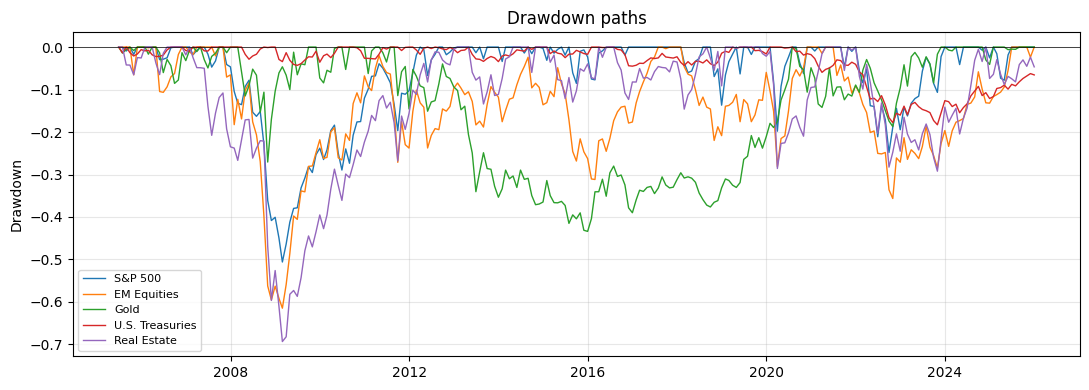

In [12]:
# Plot drawdown paths for a few representative assets
shown = ["S&P 500", "EM Equities", "Gold", "U.S. Treasuries", "Real Estate"]
cum = (prices[shown] / prices[shown].iloc[0])
dd_path = cum / cum.cummax() - 1

fig, ax = plt.subplots(figsize=(11, 4))
for col in shown:
    ax.plot(dd_path.index, dd_path[col], label=col, linewidth=1.0)
ax.set_title("Drawdown paths")
ax.set_ylabel("Drawdown")
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 4.2 Risk-return scatter

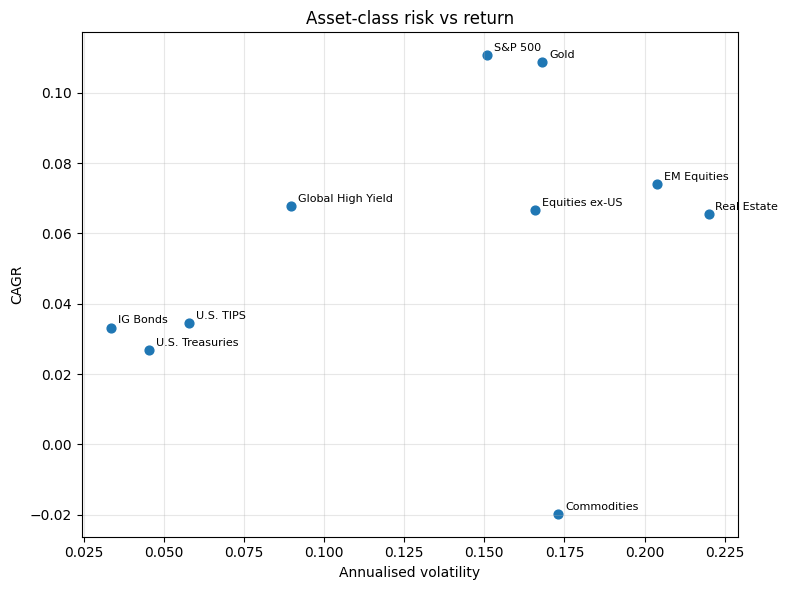

In [13]:
vol = metrics.loc["calc_volatility"]
cagr = metrics.loc["calc_cagr"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(vol, cagr, s=40)
for name in vol.index:
    ax.annotate(name, (vol[name], cagr[name]), fontsize=8, xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("CAGR")
ax.set_title("Asset-class risk vs return")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Portfolio returns from weights

Using portfolio additivity, $R_{p,t} = w^\top R_t$.
We generate 200 random long-only fully-invested weight vectors, compute their portfolio return
series, and look at the risk-return cloud.

In [14]:
rng = np.random.default_rng(42)

def random_weights(n_assets: int, n_trials: int, asset_names: list[str]) -> pd.DataFrame:
    raw = rng.random((n_assets, n_trials))
    raw /= raw.sum(axis=0, keepdims=True)
    return pd.DataFrame(raw, index=asset_names)

n_trials = 200
weights = random_weights(R.shape[1], n_trials, R.columns.tolist())
portfolios = R @ weights                # T x n_trials of simple portfolio returns
pf_prices = (1 + portfolios).cumprod() * 100
pf_prices.columns = [f"P{i:03d}" for i in pf_prices.columns]

pf_metrics = TimeseriesAnalyzer(pf_prices).apply_standard_functions()
pf_metrics.loc[["calc_cagr", "calc_volatility", "calc_sharpe_ratio"]].T.describe().round(4)

,calc_cagr,calc_volatility,calc_sharpe_ratio
count,200.0000,200.0000,200.0000
unique,200.0000,200.0000,200.0000
top,0.0548,0.0854,0.6690
freq,1.0000,1.0000,1.0000


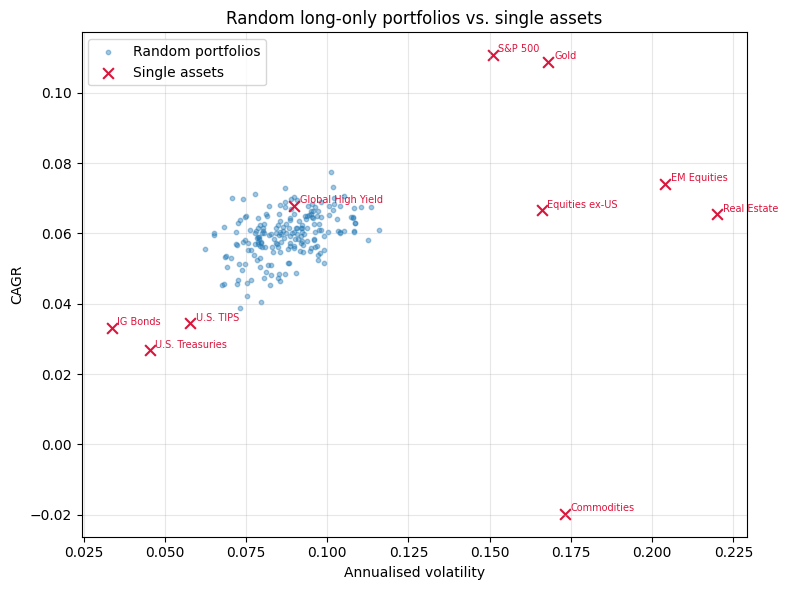

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pf_metrics.loc["calc_volatility"], pf_metrics.loc["calc_cagr"],
           s=10, alpha=0.4, label="Random portfolios")
ax.scatter(vol, cagr, s=60, c="crimson", marker="x", label="Single assets")
for name in vol.index:
    ax.annotate(name, (vol[name], cagr[name]), fontsize=7, xytext=(4, 2),
                textcoords="offset points", color="crimson")
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("CAGR")
ax.set_title("Random long-only portfolios vs. single assets")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 6. Classic stock / bond mixes

A standard pedagogical benchmark: blends of US equities and US Treasuries from 0/100 to 100/0.
Here we still aggregate via portfolio additivity (`R_p = w^T R`) — every cell rebalances at the
data frequency, with no transaction cost.

In [16]:
classic_w = pd.DataFrame(
    np.array([[0.0, 0.25, 0.5, 0.75, 1.0],
              [1.0, 0.75, 0.5, 0.25, 0.0]]),
    index=["S&P 500", "U.S. Treasuries"],
    columns=["Bonds", "25/75", "50/50", "75/25", "Stocks"],
)
classic_R = R[classic_w.index] @ classic_w
classic_prices = (1 + classic_R).cumprod() * 100

TimeseriesAnalyzer(classic_prices).apply_standard_functions().loc[
    ["calc_cagr", "calc_arithmetic_mean_return", "calc_volatility",
     "calc_sharpe_ratio", "calc_max_drawdown__max_drawdown"]
].round(4)

,Bonds,25/75,50/50,75/25,Stocks
calc_cagr,0.0275,0.0499,0.0711,0.0908,0.1091
calc_arithmetic_mean_return,0.0282,0.0500,0.0719,0.0937,0.1155
calc_volatility,0.0453,0.0492,0.0776,0.1132,0.1511
calc_sharpe_ratio,0.6226,1.0157,0.9264,0.8274,0.7644
calc_max_drawdown__max_drawdown,-0.1829,-0.1598,-0.2420,-0.3859,-0.5059


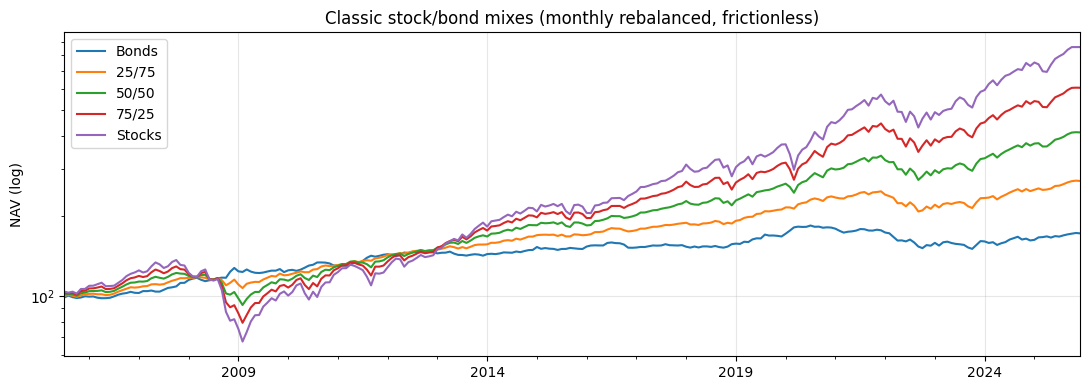

In [17]:
ax = classic_prices.plot(figsize=(11, 4), logy=True)
ax.set_title("Classic stock/bond mixes (monthly rebalanced, frictionless)")
ax.set_ylabel("NAV (log)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Walk-forward backtest with `Backtester`

The frictionless `R_p = w^T R` aggregation hides two real-world frictions:

1. **Drift between rebalances** — weights are not equal to the target between trades.
2. **Transaction costs** — trading the gap to target costs money.

`backtesting.Backtester` runs the full loop:

- converts price levels (`-i` columns) to returns internally
- drifts the holdings between rebalance dates
- on each rebalance date asks the `Strategy` for target weights and applies one-way TC
- returns a `BacktestResult` whose `nav` plugs straight into `TimeseriesAnalyzer`

A `Strategy` is anything with the signature `compute_weights(data, as_of, current_weights) -> pd.Series`.
For a constant-weight portfolio that is a one-line class.

In [18]:
class ConstantWeightStrategy:
    """Always rebalance to the same target weights."""
    def __init__(self, target: pd.Series) -> None:
        self.target = target
    def compute_weights(self, data, as_of, current_weights):
        return self.target

# Use the original (un-rescaled) price-level series for the backtester.
perf_prices = perf[list(asset_map)].rename(columns=asset_map).dropna()

portfolios_def: dict[str, dict[str, float]] = {
    "Risk-free": {"Money market": 1.00},
    "0/100 EQ/FI": {"S&P 500": 0.00, "U.S. Treasuries": 1.00},
    "20/80 EQ/FI": {"S&P 500": 0.20, "U.S. Treasuries": 0.80},
    "40/60 EQ/FI": {"S&P 500": 0.40, "U.S. Treasuries": 0.60},
    "60/40 EQ/FI": {"S&P 500": 0.60, "U.S. Treasuries": 0.40},
    "80/20 EQ/FI": {"S&P 500": 0.80, "U.S. Treasuries": 0.20},
    "100/0 EQ":    {"S&P 500": 1.00, "U.S. Treasuries": 0.00},
}

config = BacktestConfig(
    initial_capital=100.0,
    transaction_cost_bps=10.0,
    rebalance_freq="YE",          # annual rebalance
    initial_weights_from_strategy=True,
)
backtester = Backtester(config)

nav_dict: dict[str, pd.Series] = {}
for name, weight_map in portfolios_def.items():
    target = pd.Series(weight_map)
    strat = ConstantWeightStrategy(target)
    res: BacktestResult = backtester.run(perf_prices[list(weight_map)], strategy=strat)
    nav_dict[name] = res.nav

nav_df = pd.DataFrame(nav_dict)
TimeseriesAnalyzer(nav_df, risk_free_col="Risk-free").apply_standard_functions().loc[
    ["calc_cagr", "calc_volatility", "calc_sharpe_ratio",
     "calc_max_drawdown__max_drawdown"]
].round(4)

,0/100 EQ/FI,20/80 EQ/FI,40/60 EQ/FI,60/40 EQ/FI,80/20 EQ/FI,100/0 EQ
calc_cagr,0.0275,0.0467,0.0646,0.0810,0.0960,0.1091
calc_volatility,0.0453,0.0456,0.0638,0.0899,0.1195,0.1511
calc_sharpe_ratio,0.1240,0.5320,0.6603,0.6613,0.6390,0.6133
calc_max_drawdown__max_drawdown,-0.1829,-0.1543,-0.1778,-0.2791,-0.3971,-0.5059


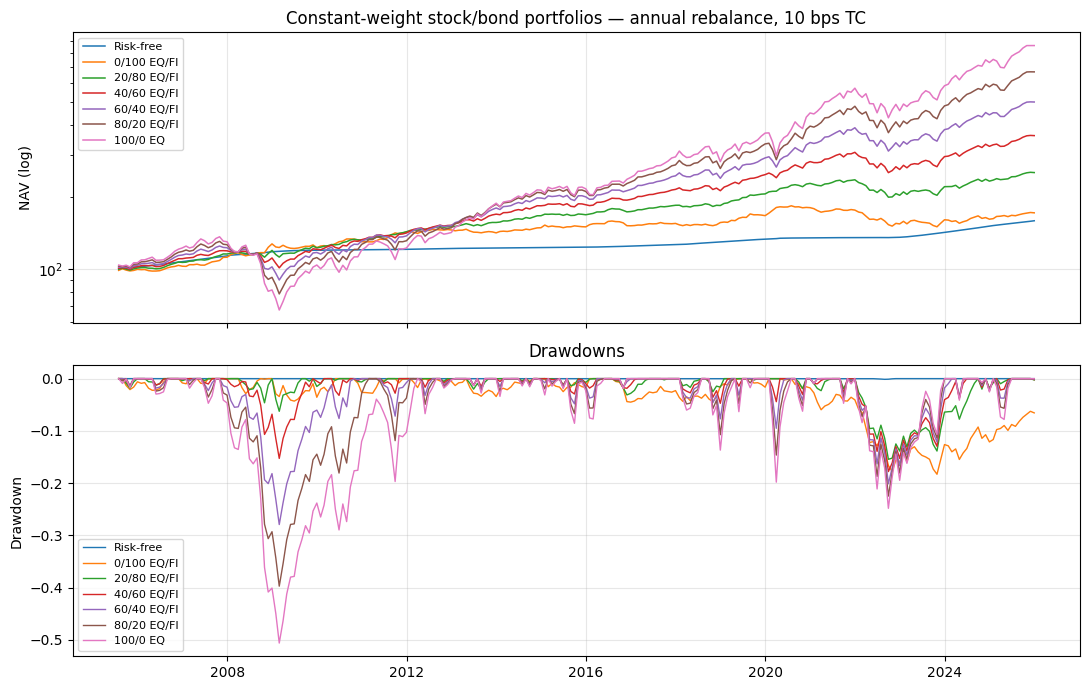

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax_nav = axes[0]
for col in nav_df.columns:
    ax_nav.plot(nav_df.index, nav_df[col], label=col, linewidth=1.1)
ax_nav.set_yscale("log")
ax_nav.set_ylabel("NAV (log)")
ax_nav.set_title("Constant-weight stock/bond portfolios — annual rebalance, 10 bps TC")
ax_nav.legend(loc="upper left", fontsize=8); ax_nav.grid(alpha=0.3)

ax_dd = axes[1]
for col in nav_df.columns:
    cum = nav_df[col] / nav_df[col].iloc[0]
    ax_dd.plot(cum.index, cum / cum.cummax() - 1, label=col, linewidth=1.0)
ax_dd.set_ylabel("Drawdown"); ax_dd.set_title("Drawdowns")
ax_dd.grid(alpha=0.3); ax_dd.legend(loc="lower left", fontsize=8)

plt.tight_layout(); plt.show()

### Trade-evaluation outputs

The `BacktestResult` also stores rebalance-level diagnostics:

- `weights_history` — target weights on each rebalance date
- `turnover` — one-way turnover at each rebalance
- `rebalance_dates` — the schedule actually used


Number of rebalances: 21
Average one-way turnover per rebalance: 0.0063
Cumulative one-way turnover:            1.5541


Text(0, 0.5, 'Weight')

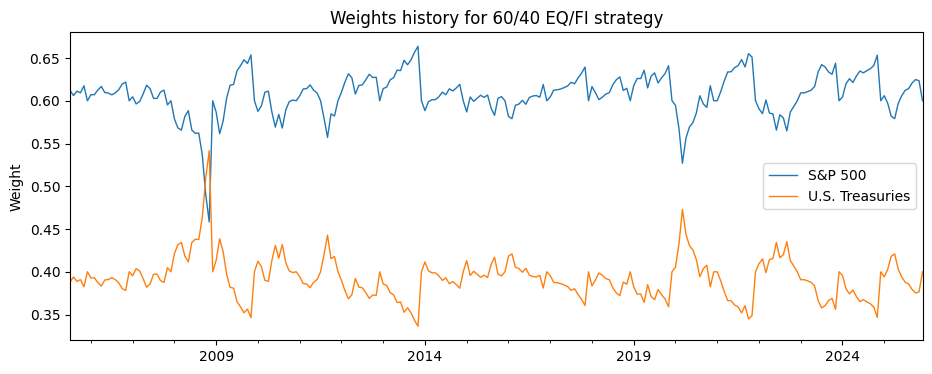

In [20]:
target = pd.Series(portfolios_def["60/40 EQ/FI"])
res = backtester.run(perf_prices[list(target.index)], strategy=ConstantWeightStrategy(target))

print(f"Number of rebalances: {len(res.rebalance_dates)}")
print(f"Average one-way turnover per rebalance: {res.turnover.mean():.4f}")
print(f"Cumulative one-way turnover:            {res.turnover.sum():.4f}")
res.weights_history.head()
res.weights_history.plot(figsize=(11, 4), linewidth=1.0)
plt.title("Weights history for 60/40 EQ/FI strategy")
plt.ylabel("Weight")

---
### Takeaways

- Simple returns are additive across assets, log returns are additive across time — use each where the additivity applies.
- Arithmetic average is the right input for portfolio expected return; geometric average is what shows up in compounded growth. They differ by roughly $\tfrac{1}{2}\sigma^2$.
- `TimeseriesAnalyzer` turns a price-level DataFrame into a full performance table; `Backtester` adds drift and transaction costs to move from `R_p = w^\top R` to a realistic NAV path.
- Even a long-only constant-weight backtest already exposes the headline behaviours we will exploit in tactical allocation later: turnover, drawdowns, and risk-adjusted return.